# AI-Powered Smart Retail & Customer Intelligence Platform

## Module 1: Product Classification

### Objective
This notebook trains an AI model to classify retail product images into different categories using MobileNetV2.

**Categories**
- Shoes
- Bags
- Clothing
- Electronics
- Grocery

In [1]:
!pip install tensorflow matplotlib numpy pandas opencv-python kaggle

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [4]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dishagupta2004","key":"7b31ecfa0242f3eb8e22136f4887d40a"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list -s retail

ref                                            title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------  ---------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mohammadtalib786/retail-sales-dataset          Retail Sales Dataset                           11509  2023-08-22 18:33:09.170000         111439        636                1  
manjeetsingh/retaildataset                     Retail Data Analytics                        3258525  2017-09-01 03:03:57.380000         111716       1132        0.8235294  
roopacalistus/superstore                       Retail Supermarket                            167457  2022-11-01 05:48:24.030000          20823        155                1  
tunguz/online-retail                           Online Retail                                7471504  2021-04-12 21:49:08.737000        

In [6]:
!kaggle datasets list -s "product image classification"

ref                                                              title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
paramaggarwal/fashion-product-images-dataset                     Fashion Product Images Dataset                     24771215740  2019-03-14 18:57:43.307000          97632        867                1  
paramaggarwal/fashion-product-images-small                       Fashion Product Images (Small)                       592614936  2019-04-26 16:33:51.490000          73713        481                1  
muratkokludataset/grapevine-leaves-image-dataset                 Grapevine Leaves Image Dataset                       113980250  2022-04-03 09:00:54.283000           9044       1554            0.8

In [7]:
!kaggle datasets list -s "grocery images"

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
validmodel/grocery-store-dataset                                Grocery Store Dataset                               123469983  2025-04-07 15:19:36.877000           4821         71  0.8235294        
trainingdatapro/ocr-receipts-text-detection                     OCR Receipts Text Detection - retail dataset         55182311  2023-09-18 14:03:30.113000           7343         82  1                
swoyam2609/fresh-and-stale-classification                       Fresh and Rotten Classification                    3053594823  2023-06-07 07:01:15.067000          12508         97  0.75             
train

In [8]:
!kaggle datasets list -s "fashion product images"

ref                                                             title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
paramaggarwal/fashion-product-images-dataset                    Fashion Product Images Dataset                 24771215740  2019-03-14 18:57:43.307000          97632        867                1  
paramaggarwal/fashion-product-images-small                      Fashion Product Images (Small)                   592614936  2019-04-26 16:33:51.490000          73713        481                1  
nirmalsankalana/fashion-product-text-images-dataset             Fashion Product Images and Text Dataset         3399462774  2024-11-12 04:00:39.700000           3295         33                1  
bhavikjikadara/e-com

In [9]:
!kaggle datasets download -d paramaggarwal/fashion-product-images-small

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
100% 565M/565M [00:08<00:00, 71.8MB/s]



In [10]:
!unzip -q fashion-product-images-small.zip -d dataset

In [11]:
import os

print(os.listdir("dataset"))

['styles.csv', 'myntradataset', 'images']


In [12]:
import pandas as pd

df = pd.read_csv("dataset/styles.csv", on_bad_lines="skip")

print("Total Products:", len(df))
df.head()

Total Products: 44424


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [13]:
print(df.columns)


Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


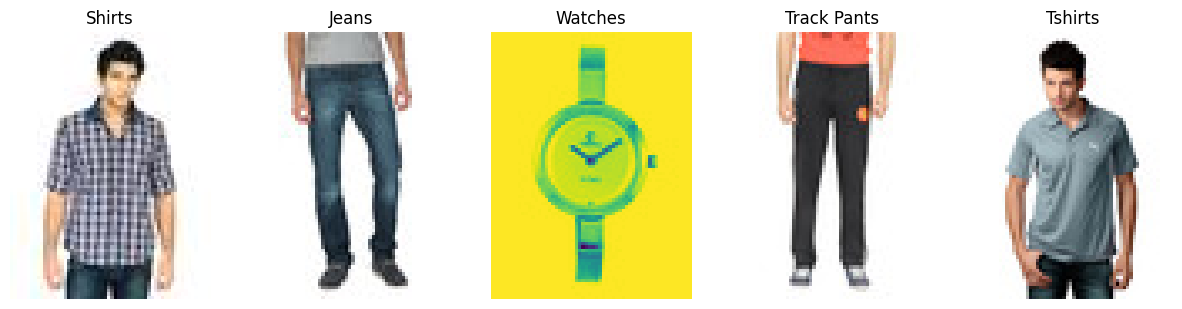

In [14]:
import matplotlib.pyplot as plt
import os

image_folder = "dataset/images"

sample_ids = df["id"].head(5)

plt.figure(figsize=(15,5))

for i, img_id in enumerate(sample_ids):
    img_path = os.path.join(image_folder, f"{img_id}.jpg")

    if os.path.exists(img_path):
        img = plt.imread(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.title(df.iloc[i]["articleType"])
        plt.axis("off")

plt.show()

In [15]:
print(df["articleType"].value_counts().head(20))

articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Name: count, dtype: int64


In [16]:
top_classes = df["articleType"].value_counts().head(10)

print(top_classes)

articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Sports Shoes    2036
Kurtas          1844
Tops            1762
Handbags        1759
Heels           1323
Sunglasses      1073
Name: count, dtype: int64


In [17]:
top_categories = df["articleType"].value_counts().head(10).index

filtered_df = df[df["articleType"].isin(top_categories)]

print("Number of images:", len(filtered_df))
filtered_df.head()

Number of images: 25468


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt


In [18]:
import os
import shutil

# Create folders
os.makedirs("train_data", exist_ok=True)

# Keep only top 10 categories
top_categories = df["articleType"].value_counts().head(10).index

filtered_df = df[df["articleType"].isin(top_categories)]

image_folder = "dataset/images"

count = 0

for _, row in filtered_df.iterrows():

    img_name = str(row["id"]) + ".jpg"

    src = os.path.join(image_folder, img_name)

    label = row["articleType"]

    dst_folder = os.path.join("train_data", label)

    os.makedirs(dst_folder, exist_ok=True)

    dst = os.path.join(dst_folder, img_name)

    if os.path.exists(src):
        shutil.copy(src, dst)
        count += 1

print("Images Copied:", count)

Images Copied: 25465


In [19]:
import os

print(os.listdir("train_data"))

['Tshirts', 'Watches', 'Tops', 'Kurtas', 'Heels', 'Sunglasses', 'Sports Shoes', 'Casual Shoes', 'Handbags', 'Shirts']


In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    "train_data",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

validation_generator = datagen.flow_from_directory(
    "train_data",
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 20376 images belonging to 10 classes.
Found 5089 images belonging to 10 classes.


In [21]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [22]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
for layer in base_model.layers:
    layer.trainable = False

In [24]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

predictions = Dense(
    train_generator.num_classes,
    activation="softmax"
)(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [25]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 77s 92ms/step - accuracy: 0.8388 - loss: 0.4381 - val_accuracy: 0.9017 - val_loss: 0.2609
Epoch 2/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8865 - loss: 0.2979 - val_accuracy: 0.8962 - val_loss: 0.2708
Epoch 3/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.8913 - loss: 0.2700 - val_accuracy: 0.9078 - val_loss: 0.2343
Epoch 4/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9006 - loss: 0.2497 - val_accuracy: 0.9080 - val_loss: 0.2490
Epoch 5/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.9073 - loss: 0.2354 - val_accuracy: 0.9153 - val_loss: 0.2235
Epoch 6/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9125 - loss: 0.2220 - val_accuracy: 0.9078 - val_loss: 0.2393
Epoch 7/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 29s 45ms/step - accuracy: 0.9118 - loss: 0.2195 - val_accuracy: 0.9114 - val_loss: 0.2283
Epoch 8/10
637/637 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.9194 - loss: 0.2040 - 

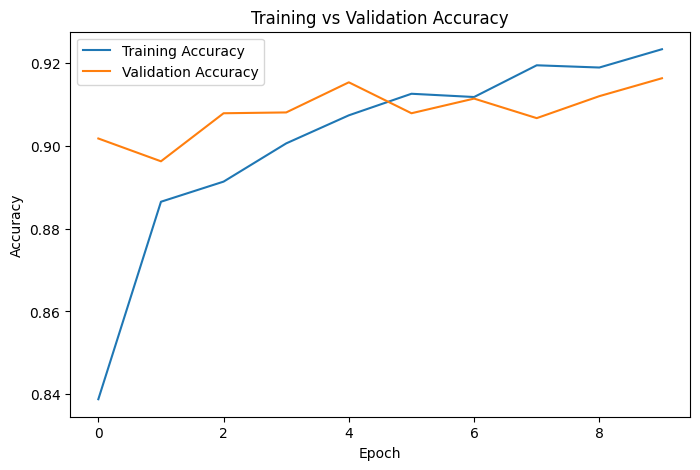

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

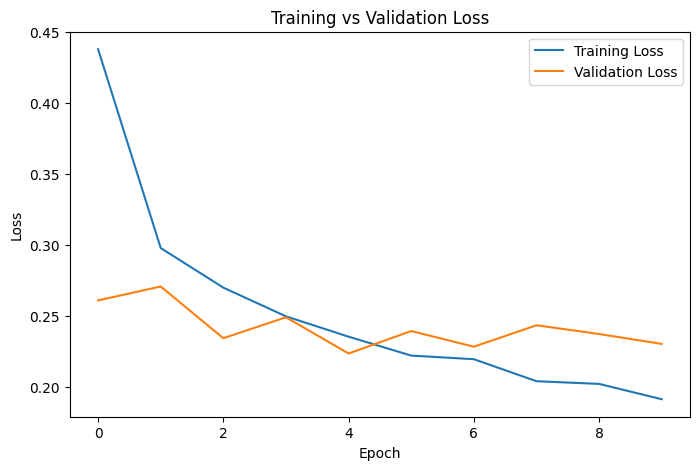

In [29]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [30]:
model.save("product_classifier.h5")

print("Model saved successfully!")

Model saved successfully!


In [31]:
# Save in the new Keras format
model.save("product_classifier.keras")

print("Both models saved successfully!")

Both models saved successfully!


In [32]:
from google.colab import files

files.download("product_classifier.h5")
files.download("product_classifier.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>